In [ ]:
"""
Temperature Forecast Data Preparation
--------------------------------------

Target:
    y = T_anom(t + lead)

Dynamic predictors (lagged):
    T_anom
    ea
    pna
    nino34
    nino12
    aao
    heatcentra

Static predictors:
    lat, lon, elevation

Seasonal predictors:
    sin_month, cos_month

No modeling performed.
"""

import sqlite3
import pandas as pd
import numpy as np
import duckdb

# ============================================================
# CONFIGURATION
# ============================================================
path="/home/joe/work/Fire/ML/Data"
path_clim="/home/joe/work/Fire/ML/Data/Climate-Indices/New"

#ERA_DB = f"{path}era5DataMeans.db"
ERA_DB = f"{path}/DB/era5MonthlyMeansFinal.sqlite"
ERA_TABLE = "MEANS_TTdRHVPD"
ERA_TABLE = "monthly_means"
CLIMATE_DB = f"{path_clim}/climate_indices.db"
CLIMATE_TABLE = "indices"

POINT_META_CSV = f"{path}/latlon_elevation.csv"

T_VAR = "T"
# T_VAR = "Td"
# T_VAR = "RH"
# T_VAR = "VPD"

# TARGET_VAR = "u"

# 'point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
#        'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
#        'days_with_vpd_gt_3'

columns = {"T":"t_mean", "Td":"td_mean", "RH":"rh_mean", "VPD":"vpd_mean"}

TARGET_VAR = columns[T_VAR]


# Train climatology window
TRAIN_CLIMO_START_YM = 1990 * 12 + 1
TRAIN_CLIMO_END_YM   = 2015 * 12 + 12

# Leads
LEADS = list(range(1, 13))

# Lags applied to ALL dynamic predictors
LAG_MONTHS = [0,1,2,3,6,24]
# LAG_MONTHS = list(range(0, 7))

# Train / test split
TEST_START_YM = 2016 * 12 + 1

# 25-point mesh center
CENTER_POINT_ID = 1116
GRID_RADIUS_DEG = 0.21


ERA   Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       'days_with_vpd_gt_3', 'year', 'month', 'ym_index'],
      dtype='object')
df cols: Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       'days_with_vpd_gt_3', 'year', 'month', 'ym_index'],
      dtype='object')
data          point_id  year_month      t_mean     td_mean    rh_mean  vpd_mean  \
1270327      2981      202511  284.004852  271.827540  47.827141  0.814604   
1270328      2981      202512  280.978013  267.189011  42.380716  0.774190   
1270329      2981      202601  277.153313  263.275849  40.117993  0.616502   
1270330      2981      202602  283.381675  266.799279  35.434584  0.974198   
1270331      2981      202603  288.811323  268.208378  29.208702  1.556216   

           tp_sum  days_with_rh_lt_20  rh_lt_20_pct  

## Get Data

In [93]:


# ============================================================
# LOAD ERA DATA
# ============================================================

def load_era():
    # conn = sqlite3.connect(ERA_DB)
    # df = pd.read_sql(f"SELECT * FROM {ERA_TABLE}", conn)
    # conn.close()
    con = duckdb.connect("/home/joe/work/Fire/ML/Data/DB/era5MonthlyMeansFinal.sqlite")

    df = con.execute(f"""
    SELECT * FROM {ERA_TABLE}
    """).df()

    con.close()
# 'point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
#        'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
#        'days_with_vpd_gt_3'


 #   df = df.rename(columns={"Point": "point_id"})
    df["year_month"] = df["year_month"].astype(int)
    df["year"] = df["year_month"] // 100
    df["month"] = df["year_month"] % 100
    df["ym_index"] = df["year"] * 12 + df["month"]

    print(f"ERA  ", df.columns)

    return df


# ============================================================
# LOAD CLIMATE INDICES
# ============================================================

def load_indices():
    conn = sqlite3.connect(CLIMATE_DB)
    idx = pd.read_sql(f"SELECT * FROM {CLIMATE_TABLE}", conn)
    conn.close()

    # idx = idx.rename(columns={
    #     "ea.data": "ea",
    #     "pna.data": "pna",
    #     "nino34.long.anom.data": "nino34",
    #     "nino12.long.anom.data": "nino12",
    #     "aao.data": "aao",
    #     "heatcentra.data": "heatcentra"
    # })

    return idx


# ============================================================
# LOAD METADATA
# ============================================================

def load_metadata():
    meta = pd.read_csv(POINT_META_CSV)
    meta = meta.rename(columns={
        "point": "point_id",
        "latitude": "lat",
        "longitude": "lon",
        "elevation_m": "elevation"
    })
    return meta


# ============================================================
# MERGE DATA
# ============================================================

def merge_all():
    df = load_era()
    print("df cols:", df.columns)
    idx = load_indices()
    indicesCols = idx.drop(columns=["yrmo"]).columns

    meta = load_metadata()

    df = df.merge(idx, left_on="year_month", right_on="yrmo", how="left")
    df = df.drop(columns=["yrmo"])

    df = df.merge(meta, on="point_id", how="left")
    print("data",df.tail())
    return df,indicesCols


# ============================================================
# SPATIAL SUBSET (25 POINT MESH)
# ============================================================

def apply_mesh(df):
    center = df.loc[df.point_id == CENTER_POINT_ID].iloc[0]
    print(f"Center point: ID {center.point_id}, lat {center.lat:.3f}, lon {center.lon:.3f}" )
    df = df[
        (np.abs(df.lat - center.lat) <= GRID_RADIUS_DEG) &
        (np.abs(df.lon - center.lon) <= GRID_RADIUS_DEG)
    ].copy()
    print("POINTS ", df['point_id'].unique())
    return df


# ============================================================
# CLIMATOLOGY + ANOMALY
# ============================================================

def compute_climatology(df):
    mask = (
        (df.ym_index >= TRAIN_CLIMO_START_YM) &
        (df.ym_index <= TRAIN_CLIMO_END_YM)
    )

    climo = (
        df.loc[mask]
          .groupby(["point_id", "month"], as_index=False)[TARGET_VAR]
          .mean()
          .rename(columns={TARGET_VAR: "T_climo"})
    )

    return climo


def apply_anomaly(df, climo):
    df = df.merge(climo, on=["point_id", "month"], how="left")
    df["T_anom"] = df[TARGET_VAR] - df["T_climo"]
    return df


# ============================================================
# SEASONAL FEATURES
# ============================================================

def add_seasonality(df):
    df["sin_month"] = np.sin(2 * np.pi * df["month"] / 12)
    df["cos_month"] = np.cos(2 * np.pi * df["month"] / 12)
    return df




def add_lags(df,DYNAMIC_FEATURES):
    df = df.sort_values(["point_id", "ym_index"])

    for feature in DYNAMIC_FEATURES:
        for lag in LAG_MONTHS:
            df[f"{feature}_lag{lag}"] = (
                df.groupby("point_id")[feature].shift(lag)
            )

    return df


# ============================================================
# BUILD FORECAST TABLE
# ============================================================

def build_forecast(df,DYNAMIC_FEATURES):

    lagged_cols = [
        f"{feat}_lag{lag}"
        for feat in DYNAMIC_FEATURES
        for lag in LAG_MONTHS
    ]

    rows = []

    for pid, df_p in df.groupby("point_id"):
        df_p = df_p.reset_index(drop=True)

        for i, issue in df_p.iterrows():

            for lead in LEADS:

                j = i + lead
                if j >= len(df_p):
                    continue

                target = df_p.loc[j]

                row = {
                    "point_id": pid,
                    "issue_ym": issue.ym_index,
                    "lead": lead,
                    "target_ym": target.ym_index,
                    "y": target.T_anom,
                    "lat": issue.lat,
                    "lon": issue.lon,
                    "elevation": issue.elevation,
                    "sin_month": issue.sin_month,
                    "cos_month": issue.cos_month
                }
                row["issue_year"] = int(issue.year)
                row["issue_month"] = int(issue.month)

                row["target_year"] = int(target.year)
                row["target_month"] = int(target.month)




                for col in lagged_cols:
                    row[col] = issue[col]

                rows.append(row)

    forecast_df = pd.DataFrame(rows)

    forecast_df = forecast_df.dropna(subset=lagged_cols).reset_index(drop=True)

    return forecast_df, lagged_cols


# ============================================================
# TRAIN / TEST SPLIT
# ============================================================

def train_test_split(forecast_df, lagged_cols):

    feature_cols = (
        lagged_cols +
        ["lead", "lat", "lon", "elevation", "sin_month", "cos_month"]
    )

    train_df = forecast_df[forecast_df.issue_ym < TEST_START_YM].copy()
    test_df  = forecast_df[forecast_df.issue_ym >= TEST_START_YM].copy()

    X_train = train_df[feature_cols].copy()
    y_train = train_df["y"].copy()

    X_test  = test_df[feature_cols].copy()
    y_test  = test_df["y"].copy()

    return X_train, X_test, y_train, y_test, train_df, test_df


# ============================================================
# MASTER PIPELINE
# ============================================================

def prepare_dataset():

    df,indCols = merge_all()
    DYNAMIC_FEATURES = [
        "T_anom"
    ] + list(indCols)

    print("DYNAMIC_FEATURES:", DYNAMIC_FEATURES)

    dfOrg = df.copy()
    df = apply_mesh(df)
    por_stats=df.groupby([ "month"])[TARGET_VAR].agg(['mean', 'std']).reset_index()

    climo = compute_climatology(df)
    df = apply_anomaly(df, climo)

    df = add_seasonality(df)
    df = add_lags(df,DYNAMIC_FEATURES)

    forecast_df, lagged_cols = build_forecast(df,DYNAMIC_FEATURES)

    return train_test_split(forecast_df, lagged_cols),por_stats,dfOrg,df,forecast_df,DYNAMIC_FEATURES


# ============================================================
# EXECUTE
# ============================================================

if __name__ == "__main__":


    (X_train, X_test, y_train, y_test, train_df, test_df), por_stats, dfOrg, df,fdf,DYNAMIC_FEATURES = prepare_dataset()

    print("X_train shape:", X_train.shape)
    print("X_test shape :", X_test.shape)
    print("Number of features:", X_train.shape[1])


ERA   Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       'days_with_vpd_gt_3', 'year', 'month', 'ym_index'],
      dtype='object')
df cols: Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       'days_with_vpd_gt_3', 'year', 'month', 'ym_index'],
      dtype='object')
data          point_id  year_month      t_mean     td_mean    rh_mean  vpd_mean  \
1270327      2981      202511  284.004852  271.827540  47.827141  0.814604   
1270328      2981      202512  280.978013  267.189011  42.380716  0.774190   
1270329      2981      202601  277.153313  263.275849  40.117993  0.616502   
1270330      2981      202602  283.381675  266.799279  35.434584  0.974198   
1270331      2981      202603  288.811323  268.208378  29.208702  1.556216   

           tp_sum  days_with_rh_lt_20  rh_lt_20_pct  

## Neural Network

In [100]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd

def run_nn_single_model(
    X_train, y_train,
    X_test, y_test,
    por_std_by_month,
    test_df
):

    # =========================
    # SCALE
    # =========================
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train.values)
    X_te = scaler.transform(X_test.values)

    y_tr = y_train.values
    y_te = y_test.values

    # =========================
    # MODEL (UNCHANGED)
    # =========================
    model = tf.keras.Sequential([
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005),
            input_shape=(X_tr.shape[1],)
        ),
        layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.0005)
        ),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss="mae"
    )

    # =========================
    # TRAIN (THIS WAS MISSING)
    # =========================
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=50,
        batch_size=256,
        callbacks=[early_stop],
        verbose=1
    )

    # =========================
    # PREDICT
    # =========================
    preds = model.predict(X_te, verbose=0).flatten()

    # =========================
    # OVERALL METRIC
    # =========================
    mae = np.mean(np.abs(preds - y_te))
    print(f"\nOverall MAE: {mae:.3f}")

    # =========================
    # MONTHLY BREAKDOWN (UNCHANGED LOGIC)
    # =========================
    results = {}

    for month in range(1, 13):

        mask = test_df["target_month"] == month

        if mask.sum() < 50:
            continue

        y_m = y_te[mask]
        p_m = preds[mask]

        mae_m = np.mean(np.abs(p_m - y_m))
        mae_norm_std = mae_m / por_std_by_month[month]['std']

        results[month] = {
            "mae": float(mae_m),
            "mae_norm_std": float(mae_norm_std),
            "n": int(len(y_m))
        }

        print(
            f"Month {month:02d} | "
            f"MAE {mae_m:.3f} | "
            f"MAE/STD {mae_norm_std:.3f}"
        )

    return results, model, scaler


# =========================
# RUN
# =========================
vv = 3
por_stats_dict = {
    int(row['month']): {'mean': row['mean'], 'std': row['std']}
    for _, row in por_stats.iterrows()
}

nn_results, model, scaler = run_nn_single_model(
    X_train, y_train,
    X_test, y_test,
    por_stats_dict,
    test_df
)

model.save(f"nn_model_{vv}.h5")
pd.DataFrame(nn_results).T.to_csv(f"nn_results_{vv}.csv", index_label="month")

print("DONE")

Epoch 1/50


/home/joe/miniconda3/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 1.4890 - val_loss: 1.9375
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.3882 - val_loss: 1.9333
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.3326 - val_loss: 1.9162
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.2881 - val_loss: 1.9276
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2533 - val_loss: 1.9116
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2226 - val_loss: 1.9511
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.2014 - val_loss: 1.9294
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1792 - val_loss: 1.9381
Epoch 9/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1613 - val_loss: 1.9504
Epoch 10/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.1469 - val_loss: 1.9355



Overall MAE: 1.830
Month 01 | MAE 2.122 | MAE/STD 0.865
Month 02 | MAE 2.364 | MAE/STD 0.998
Month 03 | MAE 2.189 | MAE/STD 0.944
Month 04 | MAE 1.006 | MAE/STD 0.576
Month 05 | MAE 1.377 | MAE/STD 0.815
Month 06 | MAE 1.474 | MAE/STD 0.752
Month 07 | MAE 1.012 | MAE/STD 0.690
Month 08 | MAE 1.204 | MAE/STD 0.848
Month 09 | MAE 1.910 | MAE/STD 1.058
Month 10 | MAE 1.660 | MAE/STD 0.874
Month 11 | MAE 2.638 | MAE/STD 0.991
Month 12 | MAE 2.687 | MAE/STD 1.144
DONE


In [103]:
test_preds = model.predict(scaler.transform(X_test.values), verbose=0).flatten()

tmp = test_df.copy()
tmp["pred"] = test_preds
tmp["abs_err"] = (tmp["pred"] - y_test.values).astype(float)

print(tmp.groupby("lead")["pred"].agg(["mean", "std", "count"]))

          mean       std  count
lead                           
1     0.484582  1.144114   2825
2     0.438178  1.072068   2800
3     0.403806  1.006843   2775
4     0.367616  0.946576   2750
5     0.324153  0.889254   2725
6     0.301983  0.838845   2700
7     0.302421  0.798921   2675
8     0.310487  0.769808   2650
9     0.313825  0.772759   2625
10    0.316893  0.795641   2600
11    0.322399  0.838785   2575
12    0.320515  0.889655   2550


In [104]:
tmp.groupby("lead")["pred"].mean()

lead
1     0.484582
2     0.438178
3     0.403806
4     0.367616
5     0.324153
6     0.301983
7     0.302421
8     0.310487
9     0.313825
10    0.316893
11    0.322399
12    0.320515
Name: pred, dtype: float32

In [102]:
tmp.groupby("lead")["abs_err"].mean()

lead
1    -0.462747
2    -0.506899
3    -0.543208
4    -0.591958
5    -0.662397
6    -0.672236
7    -0.669502
8    -0.675477
9    -0.668999
10   -0.634818
11   -0.595716
12   -0.610943
Name: abs_err, dtype: float64

In [106]:
X_scaled_check = scaler.transform(df_forecast_input[X_train.columns].values)

print(X_scaled_check.mean(), X_scaled_check.std())

0.16733616870903192 1.1510581750804127


In [108]:
print(df_issue[[c for c in df_issue.columns if "T_anom_lag" in c]])

      T_anom_lag0  T_anom_lag1  T_anom_lag2  T_anom_lag3  T_anom_lag6  \
5537     6.991401     6.274501     2.771536     6.534691      0.80496   

      T_anom_lag24  
5537     -2.181436  


<Axes: title={'center': 'Point 0, 2010-2012'}>

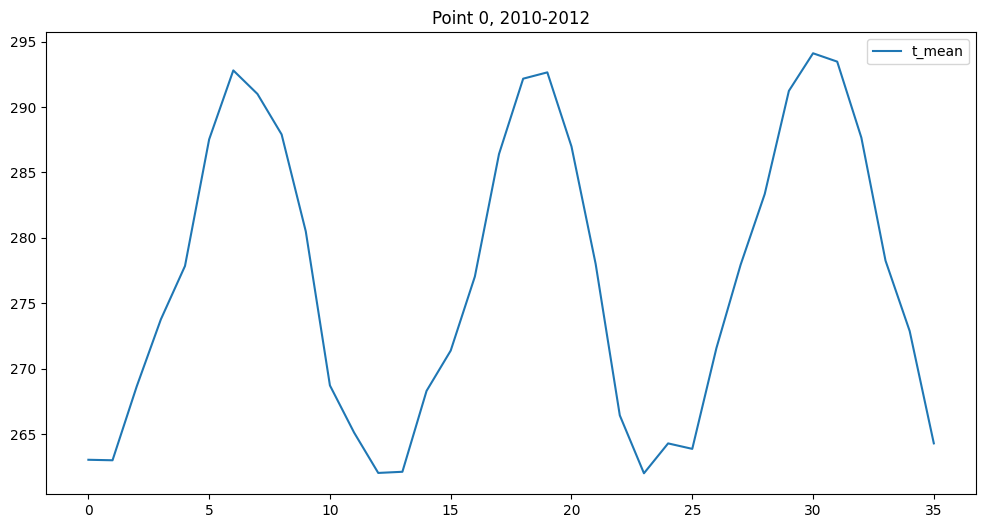

In [65]:
a=dfOrg.loc[(dfOrg['point_id'] == 0) & (dfOrg['year'] >= 2010) & (dfOrg['year'] <= 2012)].reset_index(drop=True)
a.plot( y=[f"{TARGET_VAR}"], figsize=(12, 6), title="Point 0, 2010-2012")

In [95]:
DYNAMIC_FEATURES

['T_anom',
 'wp',
 'nina4',
 'nao',
 'nina34',
 'ea',
 'soi',
 'ao',
 'nina1_anom',
 'nina34_anom',
 'nina3',
 'nina1',
 'pna',
 'nina4_anom',
 'nina3_anom']

## Forecast

In [99]:
import pandas as pd

# =========================
# CONFIG
# =========================
ISSUE_YM = 2026 * 12 + 3   # March 2026

# DYNAMIC_FEATURES = [
#     "T_anom", "ea", "pna", "nino34", "nino12", "aao", "heatcentra"
# ]

LAG_MONTHS = [0,1,2,3,6,24]

# =========================
# BUILD LAGGED FEATURE LIST
# =========================
lagged_cols = [
    f"{feat}_lag{lag}"
    for feat in DYNAMIC_FEATURES
    for lag in LAG_MONTHS
]

# =========================
# BUILD MODEL INPUT DATASET
# =========================
# df must already have:
# merge_all → apply_mesh → apply_anomaly → add_seasonality → add_lags

df_model = df.dropna(subset=lagged_cols).copy()

# =========================
# GET ISSUE ROW (MARCH 2026)
# =========================
#df_issue = df_model[df_model["ym_index"] == ISSUE_YM].copy()

#CENTER_POINT = 1116

df_issue = df_model[
    (df_model["ym_index"] == ISSUE_YM) &
    (df_model["point_id"] == CENTER_POINT_ID)
].copy()



if df_issue.empty:
    raise ValueError("No March 2026 rows found — check lag creation")

# OPTIONAL: focus on single point
# df_issue = df_issue[df_issue["point_id"] == 1116]

# =========================
# BUILD FORECAST INPUT (LEADS 1–12)
# =========================
rows = []

for lead in range(1, 13):
    tmp = df_issue.copy()
    tmp["lead"] = lead
    rows.append(tmp)

df_forecast_input = pd.concat(rows, ignore_index=True)

# =========================
# MATCH TRAINING FEATURES
# =========================
feature_cols = X_train.columns.tolist()
X_input = df_forecast_input[feature_cols]

# =========================
# SCALE + PREDICT
# =========================
X_scaled = scaler.transform(X_input.values)
preds = model.predict(X_scaled, verbose=0).flatten()

df_forecast_input["prediction"] = preds

# =========================
# BUILD FORECAST DATES
# =========================
start = pd.Timestamp("2026-03-01")

df_forecast_input["forecast_date"] = [
    start + pd.DateOffset(months=int(l))
    for l in df_forecast_input["lead"]
]

df_forecast_input["target_month"] = df_forecast_input["forecast_date"].dt.month

# =========================
# ADD CLIMATOLOGY + ANOMALY
# =========================
df_forecast_input["climo"] = df_forecast_input["target_month"].map(
    lambda m: por_stats_dict[m]["mean"]
)

df_forecast_input["anomaly"] = (
    df_forecast_input["prediction"] + df_forecast_input["climo"]
)

# =========================
# FINAL OUTPUT
# =========================
df_forecast = df_forecast_input[[
    "point_id",
    "ym_index",
    "lead",
    "forecast_date",
    "target_month",
    "prediction",
    "climo",
    "anomaly"
]].copy()

print(df_forecast.head(20))

    point_id  ym_index  lead forecast_date  target_month  prediction  \
0       1116     24315     1    2026-04-01             4   -0.505687   
1       1116     24315     2    2026-05-01             5   -0.576237   
2       1116     24315     3    2026-06-01             6   -0.636240   
3       1116     24315     4    2026-07-01             7   -0.690198   
4       1116     24315     5    2026-08-01             8   -0.734201   
5       1116     24315     6    2026-09-01             9   -0.778811   
6       1116     24315     7    2026-10-01            10   -0.830175   
7       1116     24315     8    2026-11-01            11   -0.877431   
8       1116     24315     9    2026-12-01            12   -0.919008   
9       1116     24315    10    2027-01-01             1   -0.959786   
10      1116     24315    11    2027-02-01             2   -1.002076   
11      1116     24315    12    2027-03-01             3   -1.065454   

         climo     anomaly  
0   282.114256  281.608569  
1   2

In [91]:
df.columns

Index(['point_id', 'year_month', 't_mean', 'td_mean', 'rh_mean', 'vpd_mean',
       'tp_sum', 'days_with_rh_lt_20', 'rh_lt_20_pct', 'vpd_gt_3_pct',
       ...
       'nina4_anom_lag2', 'nina4_anom_lag3', 'nina4_anom_lag6',
       'nina4_anom_lag24', 'nina3_anom_lag0', 'nina3_anom_lag1',
       'nina3_anom_lag2', 'nina3_anom_lag3', 'nina3_anom_lag6',
       'nina3_anom_lag24'],
      dtype='object', length=125)

In [13]:
full_df[full_df["issue_ym"] == ISSUE_YM]

,point_id,issue_ym,lead,target_ym,y,lat,lon,elevation,sin_month,cos_month,...,aao_lag2,aao_lag3,aao_lag6,aao_lag24,heatcentra_lag0,heatcentra_lag1,heatcentra_lag2,heatcentra_lag3,heatcentra_lag6,heatcentra_lag24


In [67]:
dfOrg['year_month'].max()

np.int64(202603)

In [12]:
full_df.head()

,point_id,issue_ym,lead,target_ym,y,lat,lon,elevation,sin_month,cos_month,...,aao_lag2,aao_lag3,aao_lag6,aao_lag24,heatcentra_lag0,heatcentra_lag1,heatcentra_lag2,heatcentra_lag3,heatcentra_lag6,heatcentra_lag24
0,972,23905.0,1,23906.0,2.090959,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
1,972,23905.0,2,23907.0,-0.025631,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
2,972,23905.0,3,23908.0,2.631396,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
3,972,23905.0,4,23909.0,1.221313,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68
4,972,23905.0,5,23910.0,-2.694774,39.8,255.9,1535.684052,0.5,0.866025,...,-0.804,-0.623,-1.22,-0.352,1.27,1.23,1.04,1.07,0.64,0.68


In [68]:
print(full_df["issue_ym"].max())
print(ISSUE_YM)

24314.0
24315


In [69]:
24312/12

2026.0

In [70]:
2026*12+2

24314

## Analysis 

In [71]:
dfOrg.tail()

,point_id,year_month,t_mean,td_mean,rh_mean,vpd_mean,tp_sum,days_with_rh_lt_20,rh_lt_20_pct,vpd_gt_3_pct,...,nina1_anom,nina34_anom,nina3,nina1,pna,nina4_anom,nina3_anom,lat,lon,elevation
1270327,2981,202511,284.004852,271.827540,47.827141,0.814604,0.009396,10.0,0.075000,0.004167,...,-0.46,-0.70,24.47,21.19,0.74,-0.52,-0.63,37.0,258.0,1105.270454
1270328,2981,202512,280.978013,267.189011,42.380716,0.774190,0.001578,17.0,0.137097,0.008065,...,-0.62,-0.67,24.43,22.19,-1.71,-0.33,-0.80,37.0,258.0,1105.270454
1270329,2981,202601,277.153313,263.275849,40.117993,0.616502,0.016245,18.0,0.133065,0.000000,...,-0.29,-0.58,25.02,24.28,0.36,-0.08,-0.64,37.0,258.0,1105.270454
1270330,2981,202602,283.381675,266.799279,35.434584,0.974198,0.002481,21.0,0.227679,0.008929,...,0.72,-0.27,26.31,26.82,-1.04,0.20,-0.10,37.0,258.0,1105.270454
1270331,2981,202603,288.811323,268.208378,29.208702,1.556216,0.000783,26.0,0.346774,0.116935,...,0.82,-0.06,27.41,27.31,-1.99,0.35,0.20,37.0,258.0,1105.270454


In [18]:
X_train

,T_anom_lag0,T_anom_lag1,T_anom_lag2,T_anom_lag3,T_anom_lag6,T_anom_lag24,ea_lag0,ea_lag1,ea_lag2,ea_lag3,...,heatcentra_lag2,heatcentra_lag3,heatcentra_lag6,heatcentra_lag24,lead,lat,lon,elevation,sin_month,cos_month
0,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,1,39.8,255.9,1535.684052,5.000000e-01,0.866025
1,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,2,39.8,255.9,1535.684052,5.000000e-01,0.866025
2,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,3,39.8,255.9,1535.684052,5.000000e-01,0.866025
3,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,4,39.8,255.9,1535.684052,5.000000e-01,0.866025
4,-3.592125,-1.428437,-4.199704,0.821486,-1.414986,0.817479,2.49,1.99,-0.69,-0.86,...,1.04,1.07,0.64,0.68,5,39.8,255.9,1535.684052,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114907,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,8,39.4,256.3,1706.128656,-2.449294e-16,1.000000
114908,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,9,39.4,256.3,1706.128656,-2.449294e-16,1.000000
114909,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,10,39.4,256.3,1706.128656,-2.449294e-16,1.000000
114910,-0.587854,-0.803378,2.615646,3.386075,0.729033,-0.478705,1.28,0.56,0.59,-1.67,...,1.51,1.48,1.27,0.26,11,39.4,256.3,1706.128656,-2.449294e-16,1.000000


In [8]:
import os


jja=0
djf=0
mam=0
son=0
fout=open(f"nn_month_loop_results_{TARGET_VAR}.txt", "w" )
for mo,dct in nn_results_month_loop.items():
    print(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}") 
    fout.write(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}\n")
    if mo in [6,7,8]:
        jja += dct['mae_norm_std']

    if mo in [12,1,2]:
        djf += dct['mae_norm_std']  
    
    if mo in [3,4,5]:
        mam += dct['mae_norm_std']
    
    if mo in [9,10,11]:
        son += dct['mae_norm_std']
fout.close()


print(f"JJA avg MAE/STD: {jja/3:.3f}")
print(f"DJF avg MAE/STD: {djf/3:.3f}")
print(f"MAM avg MAE/STD: {mam/3:.3f}")
print(f"SON avg MAE/STD: {son/3:.3f}")
fout = open(f"nn_month_loop_results_summary.txt", "a")
if not os.path.exists("nn_month_loop_results_summary.txt"):
    fout.write("target_var,jja_mae_norm_std,djf_mae_norm_std,mam_mae_norm_std,son_mae_norm_std\n")
fout.write(f"{TARGET_VAR},{jja/3:.3f},{djf/3:.3f},{mam/3:.3f},{son/3:.3f}\n")
fout.close()

NameError: name 'nn_results_month_loop' is not defined

In [22]:
dd = pd.read_csv("por_baseline_mae_by_month_lags_3_24.csv")
stats={}
for col in dd.columns:
    if col != "month":
        jja = dd.loc[dd.month.isin([6,7,8]), col].mean()
        djf = dd.loc[dd.month.isin([12,1,2]), col].mean()
        mam = dd.loc[dd.month.isin([3,4,5]), col].mean()
        son = dd.loc[dd.month.isin([9,10,11]), col].mean()

        stats[col] = {
            "JJA": jja,
            "DJF": djf,
            "MAM": mam,
            "SON": son
        }
stats 

{'lag3': {'JJA': np.float64(0.8686666666666666),
  'DJF': np.float64(0.9696666666666666),
  'MAM': np.float64(0.8293333333333335),
  'SON': np.float64(1.0663333333333334)},
 'lag6': {'JJA': np.float64(0.876),
  'DJF': np.float64(0.9556666666666667),
  'MAM': np.float64(0.848),
  'SON': np.float64(1.0813333333333333)},
 'lag12': {'JJA': np.float64(0.9033333333333333),
  'DJF': np.float64(1.083),
  'MAM': np.float64(0.907),
  'SON': np.float64(1.1336666666666666)},
 'lag24': {'JJA': np.float64(0.8566666666666666),
  'DJF': np.float64(0.9440000000000001),
  'MAM': np.float64(0.8466666666666667),
  'SON': np.float64(1.0453333333333334)}}

In [27]:
jja=0
djf=0
mam=0
son=0

for mo,dct in nn_results_month_loop.items():
    print(f"Month {mo:02d} | MAE: {dct['mae']:.3f} | MAE/STD: {dct['mae_norm_std']:.3f}") 
    if mo in [6,7,8]:
        jja += dct['mae_norm_std']

    if mo in [12,1,2]:
        djf += dct['mae_norm_std']  
    
    if mo in [3,4,5]:
        mam += dct['mae_norm_std']
    
    if mo in [9,10,11]:
        son += dct['mae_norm_std']

print(f"JJA avg MAE/STD: {jja/3:.3f}")
print(f"DJF avg MAE/STD: {djf/3:.3f}")
print(f"MAM avg MAE/STD: {mam/3:.3f}")
print(f"SON avg MAE/STD: {son/3:.3f}")

stats['NEW'] = {"JJA":jja/3, "DJF":djf/3, "MAM":mam/3, "SON":son/3}
fout = open(f"seasonal_skill_comparison_{TARGET_VAR}.csv", "w")
fout.write("Model,Season,JJA_MAE_STD,DJF_MAE_STD,MAM_MAE_STD,SON_MAE_STD\n")
for k,d in stats.items():
    fout.write(f"{k:6s} , {d['JJA']:.3f} , {d['DJF']:.3f} , {d['MAM']:.3f} , {d['SON']:.3f}\n")
fout.close()

Month 01 | MAE: 1.994 | MAE/STD: 0.853
Month 02 | MAE: 2.216 | MAE/STD: 1.009
Month 03 | MAE: 1.756 | MAE/STD: 0.861
Month 04 | MAE: 0.977 | MAE/STD: 0.555
Month 05 | MAE: 1.475 | MAE/STD: 0.878
Month 06 | MAE: 1.724 | MAE/STD: 0.858
Month 07 | MAE: 0.906 | MAE/STD: 0.620
Month 08 | MAE: 1.060 | MAE/STD: 0.736
Month 09 | MAE: 2.443 | MAE/STD: 1.314
Month 10 | MAE: 2.156 | MAE/STD: 1.070
Month 11 | MAE: 2.577 | MAE/STD: 0.990
Month 12 | MAE: 2.122 | MAE/STD: 0.955
JJA avg MAE/STD: 0.738
DJF avg MAE/STD: 0.939
MAM avg MAE/STD: 0.765
SON avg MAE/STD: 1.124


In [24]:
print(f'   NEW  {stats["NEW"]["JJA"]:<6.3f}  {stats["NEW"]["DJF"]:<6.3f}  {stats["NEW"]["MAM"]:<6.3f}  {stats["NEW"]["SON"]:<6.3f}')
print(f'  LAG3  {stats["lag3"]["JJA"]:<6.3f}  {stats["lag3"]["DJF"]:<6.3f}  {stats["lag3"]["MAM"]:<6.3f}  {stats["lag3"]["SON"]:<6.3f}')
print(f'  LAG6  {stats["lag6"]["JJA"]:<6.3f}  {stats["lag6"]["DJF"]:<6.3f}  {stats["lag6"]["MAM"]:<6.3f}  {stats["lag6"]["SON"]:<6.3f}')
print(f' LAG12  {stats["lag12"]["JJA"]:<6.3f}  {stats["lag12"]["DJF"]:<6.3f}  {stats["lag12"]["MAM"]:<6.3f}  {stats["lag12"]["SON"]:<6.3f}')
print(f' LAG24  {stats["lag24"]["JJA"]:<6.3f}  {stats["lag24"]["DJF"]:<6.3f}  {stats["lag24"]["MAM"]:<6.3f}  {stats["lag24"]["SON"]:<6.3f}')

   NEW  0.738   0.939   0.765   1.124 
  LAG3  0.869   0.970   0.829   1.066 
  LAG6  0.876   0.956   0.848   1.081 
 LAG12  0.903   1.083   0.907   1.134 
 LAG24  0.857   0.944   0.847   1.045 


| Month | lag3  | lag6  | lag12 | lag24 |
| ----- | ----- | ----- | ----- | ----- |
| 1     | 0.747 | 0.800 | 0.793 | 0.787 |
| 2     | 0.982 | 0.887 | 1.017 | 0.925 |
| 3     | 0.996 | 0.883 | 0.926 | 1.003 |
| 4     | 0.680 | 0.814 | 0.736 | 0.626 |
| 5     | 0.812 | 0.847 | 1.059 | 0.911 |
| 6     | 1.015 | 1.159 | 0.965 | 1.097 |
| 7     | 0.690 | 0.697 | 0.944 | 0.653 |
| 8     | 0.901 | 0.772 | 0.801 | 0.820 |
| 9     | 1.228 | 1.247 | 1.431 | 1.066 |
| 10    | 1.016 | 1.003 | 1.029 | 1.080 |
| 11    | 0.955 | 0.994 | 0.941 | 0.990 |
| 12    | 1.180 | 1.180 | 1.439 | 1.120 |


In [10]:
dd.to_csv("por_baseline_mae_by_month_lags_3_24.csv", index=False)

In [47]:
import pandas as pd
import glob
import os

# 1. Define the path where you saved your wget files
path = '/home/joe/work/Fire/ML/Data/Climate-Indices/New'
all_files = glob.glob(os.path.join(path, "*.data"))  # Change extension if needed (.txt, .tsv, etc.)

# 2. Use a loop to read them in and keep only rows that start with a 4-digit year
data_frames = []

for filename in all_files:
    df = pd.read_csv(
        filename,
        sep=r"\s+",
        header=None,
        skiprows=1,
        engine="python",
        on_bad_lines="skip",
        dtype=str,
    )

    year_text = df[0].astype(str).str.strip()
    year_mask = year_text.str.fullmatch(r"\d{4}")
    df = df.loc[year_mask].copy()
    df[0] = year_text.loc[year_mask].astype(int)

    # Convert the remaining columns back to numeric where possible.
    for column in df.columns[1:]:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df['source_file'] = os.path.basename(filename)
    data_frames.append(df)

# 3. Merge everything into one DataFrame
df_master = pd.concat(data_frames, ignore_index=True)

print(f"Successfully loaded {len(data_frames)} files.")

value_cols = list(range(1, 13))
dataFramesOut=[]
for df in data_frames:
    file = df['source_file'].unique()[0]
    df[0] = pd.to_numeric(df[0], errors="coerce")  
    df = df.loc[df[0].between(1990, 2026)]    
    count = (df[value_cols] < -99).sum().sum()   
    if count > 9:
        continue    
    if df[0].max() < 2026 or df[0].min() < 1990:
        continue
    print(file, count, df[0].min(), df[0].max(), df.isna().sum().sum())
    dataFramesOut.append(df)

Successfully loaded 25 files.
wp.data 9 1990 2026 0
nina4.data 9 1990 2026 0
nao.data 9 1990 2026 0
nina34.data 9 1990 2026 0
ea.data 9 1990 2026 0
soi.data 9 1990 2026 0
ao.data 9 1990 2026 0
nina1.anom.data 9 1990 2026 0
nina34.anom.data 9 1990 2026 0
nina3.data 9 1990 2026 0
nina1.data 9 1990 2026 0
pna.data 9 1990 2026 0
nina4.anom.data 9 1990 2026 0
nina3.anom.data 9 1990 2026 0


In [53]:
long_frames = []

for df in dataFramesOut:
    index_name = os.path.splitext(df['source_file'].unique()[0])[0].replace(".", "_")

    # Melt the 12 month columns (1–12) into rows
    melted = df.melt(id_vars=[0], value_vars=list(range(1, 13)),
                     var_name="month", value_name=index_name)

    # Build YYYYMM key
    melted["yrmo"] = melted[0].astype(int) * 100 + melted["month"].astype(int)

    # Replace missing-value flags with NaN
    melted.loc[melted[index_name] < -99, index_name] = float("nan")

    melted = melted[["yrmo", index_name]].sort_values("yrmo").reset_index(drop=True)
    long_frames.append(melted)

# Merge all indices on yrmo
from functools import reduce
idx_new = reduce(lambda a, b: a.merge(b, on="yrmo", how="outer"), long_frames)
idx_new = idx_new.sort_values("yrmo").reset_index(drop=True)

# Remove months where every index value is missing
value_cols = [c for c in idx_new.columns if c != "yrmo"]
idx_new = idx_new.dropna(subset=value_cols, how="all").reset_index(drop=True)

print(idx_new.shape)
print(idx_new.head())

# Persist to the new DB
DB_PATH_NEW = os.path.join(path_clim, "New", "climate_indices.db")
with sqlite3.connect(DB_PATH_NEW) as conn:
    idx_new.to_sql("indices", conn, if_exists="replace", index=False)
    print(f"\nWrote indices table ({len(idx_new)} rows × {len(idx_new.columns)} cols) → {DB_PATH_NEW}")

(435, 15)
     yrmo    wp  nina4   nao  nina34    ea  soi     ao  nina1_anom  \
0  199001  1.37  28.48  0.70   26.56  0.18 -0.1  1.001       -0.48   
1  199002  0.24  28.58  1.16   26.96 -0.14 -3.0  3.402       -0.16   
2  199003 -0.13  28.63  1.13   27.33 -0.03 -0.7  2.990       -0.44   
3  199004 -0.84  28.75  2.03   27.90 -1.11  0.3  1.879       -0.52   
4  199005  0.17  28.85 -1.37   28.02  2.25  2.0  0.943       -0.24   

   nina34_anom  nina3  nina1   pna  nina4_anom  nina3_anom  
0         0.01  25.37  24.09 -1.09        0.16       -0.29  
1         0.21  26.42  25.94 -2.78        0.38        0.01  
2         0.04  26.92  26.04  0.04        0.31       -0.28  
3         0.08  27.49  25.02 -0.62        0.12       -0.10  
4         0.08  27.41  24.18  0.27       -0.06        0.16  

Wrote indices table (435 rows × 15 cols) → /home/joe/work/Fire/ML/Data/Climate-Indices/New/climate_indices.db


In [54]:
DB_PATH_NEW = os.path.join(path_clim, "New", "climate_indices.db")

conn = sqlite3.connect(DB_PATH_NEW)
idx = pd.read_sql(f"SELECT * FROM indices", conn)
conn.close()

# idx = idx.rename(columns={
#     "ea.data": "ea",
#     "pna.data": "pna",
#     "nino34.long.anom.data": "nino34",
#     "nino12.long.anom.data": "nino12",
#     "aao.data": "aao",
#     "heatcentra.data": "heatcentra"
# })

In [56]:
idx.columns

Index(['yrmo', 'wp', 'nina4', 'nao', 'nina34', 'ea', 'soi', 'ao', 'nina1_anom',
       'nina34_anom', 'nina3', 'nina1', 'pna', 'nina4_anom', 'nina3_anom'],
      dtype='object')

In [60]:
idx.drop(columns=["yrmo"]).columns

Index(['wp', 'nina4', 'nao', 'nina34', 'ea', 'soi', 'ao', 'nina1_anom',
       'nina34_anom', 'nina3', 'nina1', 'pna', 'nina4_anom', 'nina3_anom'],
      dtype='object')